This dataset contains road images labeled into two classes:

- normal: images without potholes

- potholes: images containing potholes

The goal is to build a binary image classification model.

In [1]:
import os

base_path = "../data"
classes = ["normal", "potholes"]

counts = {}
for c in classes:
    counts[c] = len(os.listdir(os.path.join(base_path, c)))

counts

{'normal': 352, 'potholes': 329}

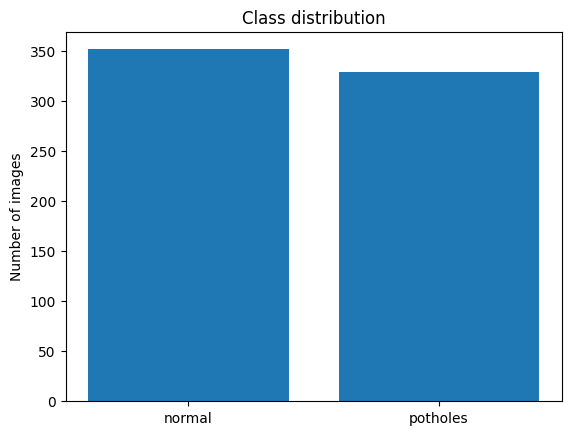

In [2]:
import matplotlib.pyplot as plt

plt.bar(counts.keys(), counts.values())
plt.title("Class distribution")
plt.ylabel("Number of images")
plt.show()

In [3]:
from PIL import Image

sample_path = os.path.join(base_path, "potholes", os.listdir(os.path.join(base_path, "potholes"))[0])
img = Image.open(sample_path)

img.size, img.mode

((980, 654), 'RGB')

In [4]:
widths = []
heights = []

for c in classes:
    folder = os.path.join(base_path, c)
    for fname in os.listdir(folder):
        img = Image.open(os.path.join(folder, fname))
        w, h = img.size
        widths.append(w)
        heights.append(h)

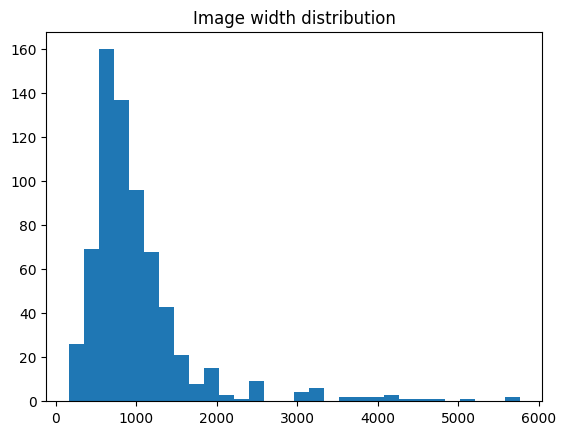

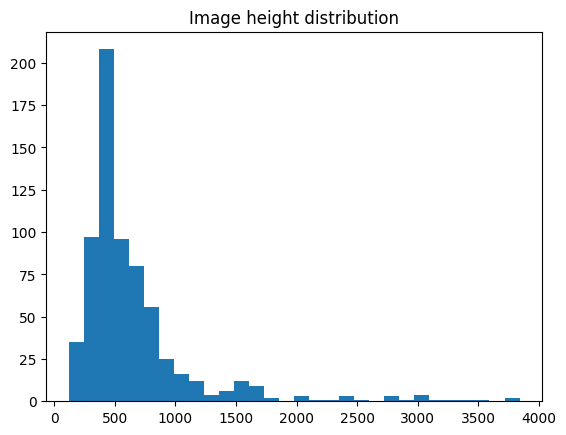

In [5]:
plt.hist(widths, bins=30)
plt.title("Image width distribution")
plt.show()

plt.hist(heights, bins=30)
plt.title("Image height distribution")
plt.show()

Images come in varying resolutions, therefore all images will be resized to a fixed size during preprocessing.

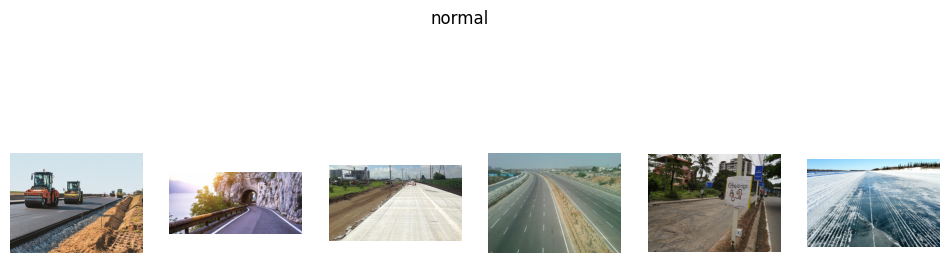

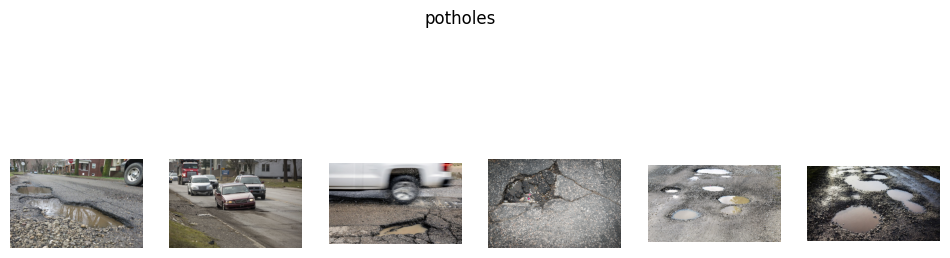

In [6]:
import matplotlib.pyplot as plt
import random

def show_images(class_name, n=6):
    folder = os.path.join(base_path, class_name)
    images = random.sample(os.listdir(folder), n)

    plt.figure(figsize=(12, 4))
    for i, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(class_name)
    plt.show()

show_images("normal")
show_images("potholes")

Potholes vary significantly in size, shape, and visibility, which increases task difficulty.